## Environment setup

Create a new anaconda environment and call it 'machinelearning'

- conda create --name machinelearning python=3.11

Install the following packages after activating the environment

- conda install ipykernel numpy pandas
- conda install anaconda::matplotlib
- conda install anaconda::seaborn
- conda install anaconda::scikit-learn

## Goals
In this lab you will:
- Learn to implement the a linear model $f_{w,b}(x)$ to be used for linear regression with one variable



## Notation

With $f_{w,b}(x)$ as a linear model of one variable, we exlicitly imply that 

$$f_{w,b}(x) = w \cdot x+b$$

The goal is to find values for $w$ and $b$ so that the model $f_{w,b}(x)$ best fits the data we train it on.

The feature and target of the $i$:th training sample will be denoted $x^{(i)}$ and $y^{(i)}$, respectively. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
#create data
x = np.array([1, 1.2, 2, 3, 4.5, 4, 5, 6, 7, 7.5, 8, 9])
y = np.array([13, 14, 17, 12, 23, 24, 25, 25, 24, 28, 32, 33])
if len(x) == len(y):
    print("Same number of elements")
else:
    print("Different number of elements")

len(x) == len(y)

x.shape[0]
y.shape[0]


Same number of elements


12

Our data now looks like this

| x (number of rooms)  | y (price in thousands of $) |
| -------------------  | ------------------------ |
| 1                  | 13                      |
| 1.2                | 14                      |
| 2                  | 17                      |
| 3                  | 12                      |
| ...                | ...                     |
| 9                  | 33                      |

The x's are our features, and the y's our targets

Our task is now to fit a linear model $f_{w,b}(x) = w \cdot x+b$ to this data, and use it to predict prices for other houses.

It is very common to call the data you train on `x_train` and `y_train`, so let's create those variables here. We'll also store the data in one-dimensional NumPy arrays, since calculations with those are faster and more convenient than with Python lists.

In [55]:
x_train = np.array(x)
y_train = np.array(y)
# x_train = x
# y_train = y
print(type(x_train))

print(f"x_train = {x_train}")
print(f"y_train = {y_train}")

<class 'numpy.ndarray'>
x_train = [1.  1.2 2.  3.  4.5 4.  5.  6.  7.  7.5 8.  9. ]
y_train = [13 14 17 12 23 24 25 25 24 28 32 33]


### Number of training examples `m`
We will use `m` to denote the number of training examples. 

In [22]:
# m is the number of training examples
m = len(x_train)
print(f"Number of training examples is: {m}")

Number of training examples is: 12


### Training example `x_i, y_i`

You will use $x^{i}$ and $y^{i}$ to denote the $i^{th}$ training example.

To access any particular training sample, we can simply index our training data.

Execude the next code block below to get the $i^{th}$ training example.

In [30]:
i = 3 # Change this to the desired number i+1 to see (x^i, y^i)

x_i = x_train[i]
print(x_i)
y_i = y_train[i]
print(y_i)
print(f"(x^({i+1}), y^({i+1})) = ({x_i}, {y_i})")

3.0
12
(x^(4), y^(4)) = (3.0, 12)


### Plotting the data

Let's plot our training data to get some intuition and better understanding of it. We can use a simply `scatter()`-plot here.


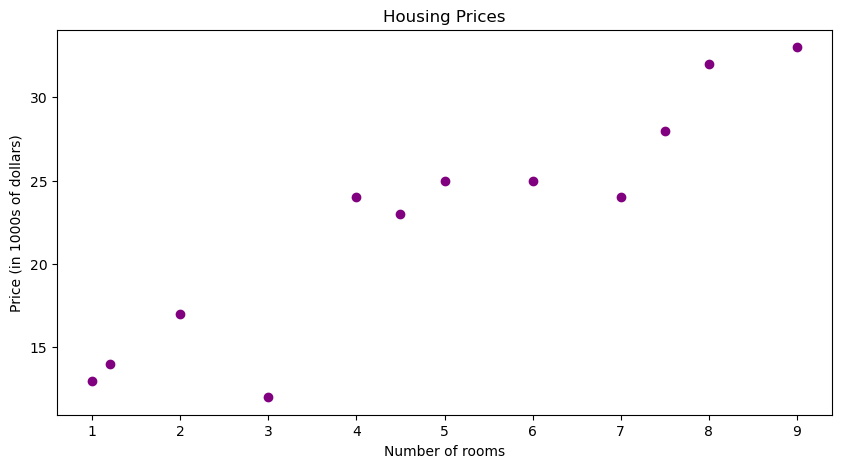

In [32]:
# Plot the data points
plt.figure(figsize= (10, 5))
plt.scatter(x_train, y_train, marker='o', c='purple')
# Set the title
plt.title("Housing Prices")
# Set the y-axis label
plt.ylabel('Price (in 1000s of dollars)')
# Set the x-axis label
plt.xlabel('Number of rooms')
plt.show()

## Model function

As described in the lecture, the model function for linear regression (which is a function that maps from `x` to `y`) is represented as 

$$ f_{w,b}(x) = w \cdot x + b$$

The formula above is how you can represent straight lines - different values of $w$ and $b$ give you different straight lines on the plot.

**Now:** Let's first create a function that, given any value of x, w and b, returns the corresponding function value y

In [33]:
# we'll create a general function that can take any values of w and b, so that it can be reused later

def linear_model(x: list, w: int | float, b: int | float):

    predicted_y = w*x + b
    
    return predicted_y




## Testing different values of w and b


Let's try to get a better intuition for linear modelling by testing out different values of $w$ and $b$, to see which one fits the data best 

Let's begin by testing $w = 1$ and $b = 10$.

In other words, our hypothesis model using these values is

$$ f_{1,10}(x) = 1 \cdot x + 10$$

**Note: You can come back to this cell to adjust the model's w and b parameters**

In [37]:
w = 1
b = 10
print(f"w: {w}")
print(f"b: {b}")

w: 1
b: 10


Now, let's assume that we have no idea what the real y-values (house prices) in our training data, and let's just use the features in our training data to predict housing prices instead. 

In [38]:
y_predictions = linear_model(x_train, w , b)

print(y_predictions)

[11.  11.2 12.  13.  14.5 14.  15.  16.  17.  17.5 18.  19. ]


What we have done is to calculate $\hat{y}^{i} = f_{1,10}(x^{i})$ for all of feature values $x^{i}$ in the training data. 

Our hope is that each $\hat{y}^i$ is close to the true $y^{i}$.

## Plotting the results

Let's plot these predicted results, together with the original data, to see what we've actually done

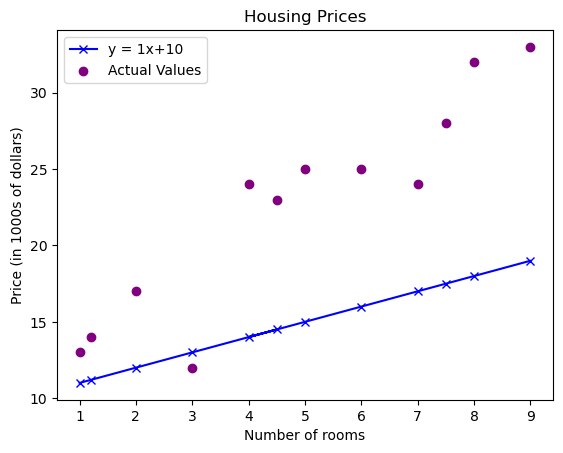

In [40]:
# Plot our model prediction
plt.plot(x_train, y_predictions, marker='x', c='b',label=f'y = {w}x+{b} ')

# Plot the data points
plt.scatter(x_train, y_train, marker='o', c='purple',label='Actual Values')

# Set the title
plt.title("Housing Prices")
# Set the y-axis label
plt.ylabel('Price (in 1000s of dollars)')
# Set the x-axis label
plt.xlabel('Number of rooms')
plt.legend()
plt.show()

As you can see, setting $w = 1$ and $b = 10$ does *not* result in a linear model that fits our data particularly well. 

## Challenges 

**Task 1**

Try experimenting with different values of $w$ and $b$. What should the values be for a line that fits our data?

## Here is the thinking process : How w and b Affect the Line:
w (slope/weight): Controls how steep the line is

Larger w → steeper upward line
Smaller w → flatter line
Negative w → downward sloping line
b (bias/intercept): Controls where the line crosses the y-axis

Larger b → line shifts up
Smaller b → line shifts down
Strategy:
Step 1: Estimate from the scatter plot
Looking at your data:

At x=1, y≈13
At x=9, y≈33
The data generally goes up as x increases
Step 2: Calculate rough slope
Slope = (change in y) / (change in x) = (33 - 13) / (9 - 1) = 20/8 = 2.5

So try w ≈ 2.5

Step 3: Estimate intercept
If w=2.5, when x=1: y = 2.5*1 + b = 13
Solving: b = 13 - 2.5 = 10.5

So try b ≈ 10.5

w: 2.5
b: 10.5
[13.   13.5  15.5  18.   21.75 20.5  23.   25.5  28.   29.25 30.5  33.  ]


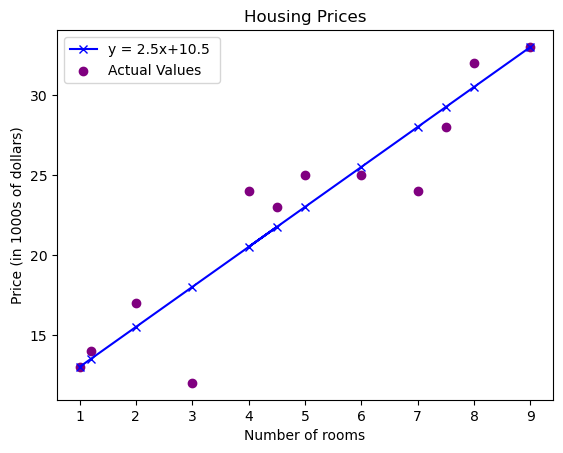

Mean squared error is : 6.364583333333333
Mean absolut error is : 1.8333333333333333
Root mean squared error is : 2.5228125838701003


In [78]:
w = 2.5
b = 10.5
print(f"w: {w}")
print(f"b: {b}")
y_predictions = linear_model(x_train, w , b)

print(y_predictions)
plt.plot(x_train, y_predictions, marker='x', c='b',label=f'y = {w}x+{b} ')

# Plot the data points
plt.scatter(x_train, y_train, marker='o', c='purple',label='Actual Values')

# Set the title
plt.title("Housing Prices")
# Set the y-axis label
plt.ylabel('Price (in 1000s of dollars)')
# Set the x-axis label
plt.xlabel('Number of rooms')
plt.legend()
plt.show()

errors = y_train -y_predictions
mse = np.mean(errors**2)
print(f"Mean squared error is : {mse}")

mae = np.mean(np.abs(errors))
print(f"Mean absolut error is : {mae}")

rmse = np.sqrt(mse)
print(f"Root mean squared error is : {rmse}")

In [85]:
models = [(1,10),(2,11),(2.5,10.5),(3,9),(2,8),(3,8),(3,9),(2.3,9),(2.5,10.5)]
for w, b in models:
    y_pred = linear_model(x_train, w, b)
    mse = np.mean((y_train - y_pred)**2)
    print(f"w={w}, b={b} → MSE={mse:.2f}")
    # Compare actual vs predicted for each point
y_predictions = linear_model(x_train, w, b)

print("Actual vs Predicted:")
for i in range(len(x_train)):
    error = abs(y_train[i] - y_predictions[i])
    print(f"x={x_train[i]:.1f}: actual={y_train[i]}, predicted={y_predictions[i]:.1f}, error={error:.1f}")

w=1, b=10 → MSE=78.53
w=2, b=11 → MSE=10.78
w=2.5, b=10.5 → MSE=6.36
w=3, b=9 → MSE=9.62
w=2, b=8 → MSE=30.58
w=3, b=8 → MSE=8.52
w=3, b=9 → MSE=9.62
w=2.3, b=9 → MSE=11.92
w=2.5, b=10.5 → MSE=6.36
Actual vs Predicted:
x=1.0: actual=13, predicted=13.0, error=0.0
x=1.2: actual=14, predicted=13.5, error=0.5
x=2.0: actual=17, predicted=15.5, error=1.5
x=3.0: actual=12, predicted=18.0, error=6.0
x=4.5: actual=23, predicted=21.8, error=1.2
x=4.0: actual=24, predicted=20.5, error=3.5
x=5.0: actual=25, predicted=23.0, error=2.0
x=6.0: actual=25, predicted=25.5, error=0.5
x=7.0: actual=24, predicted=28.0, error=4.0
x=7.5: actual=28, predicted=29.2, error=1.2
x=8.0: actual=32, predicted=30.5, error=1.5
x=9.0: actual=33, predicted=33.0, error=0.0


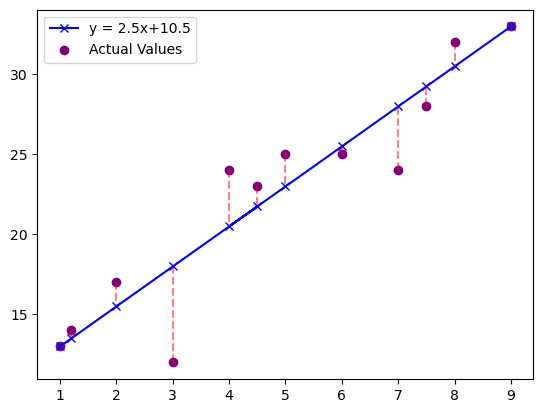

In [86]:
plt.plot(x_train, y_predictions, marker='x', c='b', label=f'y = {w}x+{b}')
plt.scatter(x_train, y_train, marker='o', c='purple', label='Actual Values')

# Draw vertical lines showing errors
for i in range(len(x_train)):
    plt.plot([x_train[i], x_train[i]], 
             [y_train[i], y_predictions[i]], 
             'r--', alpha=0.5)

plt.legend()
plt.show()

In [87]:
best_mse = float('inf')
best_model = None

for w, b in models:
    y_pred = linear_model(x_train, w, b)
    mse = np.mean((y_train - y_pred)**2)
    if mse < best_mse:
        best_mse = mse
        best_model = (w, b)

print(f"Best model: w={best_model[0]}, b={best_model[1]} with MSE={best_mse:.2f}")


Best model: w=2.5, b=10.5 with MSE=6.36


In [88]:
# Method 1: Using NumPy's polyfit
coefficients = np.polyfit(x_train, y_train, 1)
w_optimal = coefficients[0]
b_optimal = coefficients[1]

print(f"Optimal w: {w_optimal:.4f}")
print(f"Optimal b: {b_optimal:.4f}")

# Verify with predictions
y_pred_optimal = linear_model(x_train, w_optimal, b_optimal)
mse_optimal = np.mean((y_train - y_pred_optimal)**2)
print(f"MSE: {mse_optimal:.2f}")

Optimal w: 2.4272
Optimal b: 10.7282
MSE: 6.31


In [89]:
from sklearn.linear_model import LinearRegression

# Reshape for sklearn
X = x_train.reshape(-1, 1)

# Fit the model
model = LinearRegression()
model.fit(X, y_train)

w_optimal = model.coef_[0]
b_optimal = model.intercept_

print(f"Optimal w: {w_optimal:.4f}")
print(f"Optimal b: {b_optimal:.4f}")

Optimal w: 2.4272
Optimal b: 10.7282


**Task 2**

Prediction

Now that we have a good model, we can use it to make an original prediction. Predict the price of a house with: 
- 7.5 bedrooms
- 10 bedrooms

Are you interpolating, or extrapolating, in each of those cases?

*Hint: look up the definitions of interpolation and extrapolation if you're not sure what they mean.*

**Task 3**

Create your own data, and try to fit a linear model (find values of w and b) on that data

# Congratulations!
In this lab you have learned:
 - Linear regression builds a model which establishes a relationship between features and targets
     - In the example above, the feature was number of houses and the target was house price
     - for simple linear regression, the model has two parameters $w$ and $b$ whose values are 'fit' using *training data*.
     - once a model's parameters have been determined, the model can be used to make predictions on novel data.